<a href="https://colab.research.google.com/github/neysap/Food-Nutrition-Data-Analysis-Classification-Model/blob/main/World_Food_Facts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction

**Project Title:** World Food Facts Project  
Neysa Porter

In this notebook, we explain the dataset, document the cleaning decisions, interpret the exploratory analysis, compare multiple models, and close with limitations and next steps.

Our main goal is to predict a product's **Nutri-Score grade (A-E)** from nutritional information in the Open Food Facts dataset. This turns the project into a multi-class classification problem with a direct real-world interpretation: can a small group of nutrition variables recover a product's overall nutrition label?


# Before Running

This notebook is designed to work in Colab or in a local Jupyter environment as long as the dataset file is available.

A few practical notes before running the cells:

- The notebook expects either `world-food-facts.csv` or the original Open Food Facts TSV file.
- The download cell below is optional if the dataset is already present in the working directory.
- We use a capped modeling sample for the heavier steps so the notebook stays practical to run.
- The final modeling task only uses rows with complete values for the active nutrition features, so the usable modeling subset is smaller than the raw dataset.


## Project Objective

The objective of this project is to predict a food product's **Nutri-Score grade (A-E)** from nutritional features in the Open Food Facts dataset.

The main questions we focus on are:

1. Can a small set of nutrition variables predict Nutri-Score effectively?
2. Does PCA help this task?
3. Which baseline model performs best?
4. Which features matter most?
5. Does light hyperparameter tuning improve the stronger tree-based models?


## Data Source

We use the **Open Food Facts** dataset, which contains millions of products from many countries together with nutritional values, categories, and other metadata. For this notebook, we focus on the columns most directly related to Nutri-Score prediction:

- `energy_100g`
- `fat_100g`
- `saturated-fat_100g`
- `carbohydrates_100g`
- `sugars_100g`
- `proteins_100g`
- `fiber_100g`
- `salt_100g`
- `nutrition_grade_fr`

We also keep simplified category and country fields as optional metadata so we can test whether context beyond raw nutrition values helps the classifiers.


## Colab Setup

If the dataset is not already present, run the next cell in Colab to download it from Kaggle using environment variables or Colab Secrets.

Important: this notebook now expects Kaggle credentials to come from secrets or environment variables. They should not be hardcoded into the notebook.


In [ ]:
# Download and normalize the dataset when running in Colab.
import os
import subprocess
import sys
import zipfile
import pandas as pd
from pathlib import Path

%env KAGGLE_USERNAME=souleydiallo
%env KAGGLE_KEY=733e9204c5c97add6e12b9b398bae4dd

try:
    from google.colab import userdata
except ImportError:
    userdata = None

IN_COLAB = 'google.colab' in sys.modules
DATA_FILENAME = "world-food-facts.csv"
DATA_FILE_CANDIDATES = [DATA_FILENAME, "en.openfoodfacts.org.products.tsv"]
COLAB_DATA_DIR = Path("/content")
COLAB_DATA_PATH = COLAB_DATA_DIR / DATA_FILENAME
KAGGLE_DATASET = os.environ.get("KAGGLE_DATASET", "openfoodfacts/world-food-facts")
KAGGLE_FILE = os.environ.get("KAGGLE_FILE") or None
DATA_URL = os.environ.get("DATA_URL") or None

def get_secret(name):
    """Return a credential from the environment or Colab secrets."""
    value = os.environ.get(name)
    if value:
        return value
    if userdata is not None:
        try:
            return userdata.get(name)
        except Exception:
            return None
    return None

def curl_download(url, destination, extra_args=None):
    """Download a file with curl and save it to the given destination."""
    destination.parent.mkdir(parents=True, exist_ok=True)
    command = ["curl", "-L", "--fail", "--show-error", "--silent"]
    if extra_args:
        command.extend(extra_args)
    command.extend([url, "-o", str(destination)])
    subprocess.run(command, check=True)

def normalize_to_csv(source_path, final_csv_path):
    """Convert the extracted dataset file to a CSV when needed."""
    if source_path.suffix.lower() == ".csv":
        if source_path != final_csv_path:
            final_csv_path.write_bytes(source_path.read_bytes())
        return final_csv_path
    if source_path.suffix.lower() == ".tsv":
        df = pd.read_csv(source_path, sep="	", low_memory=False)
        df.to_csv(final_csv_path, index=False)
        return final_csv_path
    raise ValueError(f"Unsupported extracted file type: {source_path}")

def download_kaggle_dataset(dataset, filename, destination_dir):
    """Download the Kaggle archive, extract the data file, and return a CSV path."""
    kaggle_username = get_secret("KAGGLE_USERNAME")
    kaggle_key = get_secret("KAGGLE_KEY")
    if not kaggle_username or not kaggle_key:
        raise RuntimeError("Set KAGGLE_USERNAME and KAGGLE_KEY in Colab Secrets or environment variables before running this cell.")

    os.environ["KAGGLE_USERNAME"] = kaggle_username
    os.environ["KAGGLE_KEY"] = kaggle_key

    destination_dir.mkdir(parents=True, exist_ok=True)
    archive_path = destination_dir / "kaggle_dataset.zip"
    api_url = f"https://www.kaggle.com/api/v1/datasets/download/{dataset}"
    curl_download(api_url, archive_path, extra_args=["-H", f"Authorization: Kaggle {kaggle_username}:{kaggle_key}"])

    if not zipfile.is_zipfile(archive_path):
        preview = archive_path.read_text(encoding="utf-8", errors="ignore")[:300]
        raise RuntimeError(
            f"Kaggle download did not return a zip archive. Check KAGGLE_DATASET and your credentials. Response preview: {preview}"
        )

    with zipfile.ZipFile(archive_path) as archive:
        names = archive.namelist()
        filename_candidates = [candidate for candidate in [filename, *DATA_FILE_CANDIDATES] if candidate]
        target_name = next((name for name in names if Path(name).name in filename_candidates), None)
        if target_name is None:
            target_name = next((name for name in names if name.endswith((".tsv", ".csv"))), None)
        if target_name is None:
            raise FileNotFoundError(f"No CSV or TSV file found in the Kaggle archive. First files: {names[:10]}")
        archive.extract(target_name, destination_dir)

    extracted_path = destination_dir / target_name
    final_path = destination_dir / Path(target_name).name
    if extracted_path != final_path:
        final_path.parent.mkdir(parents=True, exist_ok=True)
        extracted_path.replace(final_path)
        extracted_path = final_path

    normalized_csv_path = destination_dir / DATA_FILENAME
    final_csv_path = normalize_to_csv(extracted_path, normalized_csv_path)

    archive_path.unlink(missing_ok=True)
    return final_csv_path

if IN_COLAB:
    if COLAB_DATA_PATH.exists():
        print(f"Found existing dataset at {COLAB_DATA_PATH}")
    elif KAGGLE_DATASET:
        print(f"Downloading Open Food Facts data from Kaggle dataset {KAGGLE_DATASET} with curl...")
        downloaded_path = download_kaggle_dataset(KAGGLE_DATASET, KAGGLE_FILE, COLAB_DATA_DIR)
        print(f"Saved {downloaded_path} ({downloaded_path.stat().st_size / (1024 ** 2):.1f} MB)")
    elif DATA_URL:
        print(f"Downloading {DATA_FILENAME} from DATA_URL to {COLAB_DATA_PATH} with curl...")
        curl_download(DATA_URL, COLAB_DATA_PATH)
        print(f"Saved {COLAB_DATA_PATH} ({COLAB_DATA_PATH.stat().st_size / (1024 ** 2):.1f} MB)")
    else:
        print("Set KAGGLE_DATASET plus Kaggle credentials, or set DATA_URL, then rerun this cell.")
else:
    print("Standard local environment detected.")


env: KAGGLE_USERNAME=souleydiallo
env: KAGGLE_KEY=733e9204c5c97add6e12b9b398bae4dd
Saved /content/world-food-facts.csv (973.7 MB)


# Package Import and Notebook Setup

This section loads the libraries, plotting style, constants, and helper functions used throughout the project.

We keep these definitions near the top so the later cells can focus on the analytical story rather than repetitive setup code. The helper functions mainly standardize formatting, sampling, and file resolution.


In [ ]:
# Import libraries and define shared helpers.
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

DATA_PATH_CANDIDATES = [
    Path("world-food-facts.csv")
]
TARGET_COL = "nutrition_grade_fr"
NUMERIC_COLS = [
    "energy_100g",
    "fat_100g",
    "saturated-fat_100g",
    "carbohydrates_100g",
    "sugars_100g",
    "proteins_100g",
    "fiber_100g",
    "salt_100g",
]
META_COLS = ["main_category_en", "countries_en"]
LABELS = ["A", "B", "C", "D", "E"]
MODEL_SAMPLE_SIZE = 500_000
TUNING_SAMPLE_SIZE = 30_000
TOP_CATEGORY_LIMIT = 50
TOP_COUNTRY_LIMIT = 30
TEST_SIZE = 0.2
RANDOM_SEED = 42

def format_count_tick(value, _):
    """Format large axis tick values in compact k/M notation."""
    if abs(value) >= 1_000_000:
        return f"{value / 1_000_000:.1f}M"
    if abs(value) >= 1_000:
        rounded = value / 1_000
        return f"{rounded:.0f}k" if float(rounded).is_integer() else f"{rounded:.1f}k"
    return f"{value:.0f}"

def format_count_axis(ax, axis="x"):
    """Apply compact count formatting to one axis of a matplotlib plot."""
    formatter = FuncFormatter(format_count_tick)
    if axis == "x":
        ax.xaxis.set_major_formatter(formatter)
    else:
        ax.yaxis.set_major_formatter(formatter)

def shorten_axis_labels(values, max_len=24):
    """Trim long categorical labels so plot axes stay readable."""
    shortened = []
    for value in values:
        text = str(value)
        shortened.append(text if len(text) <= max_len else text[: max_len - 1] + "...")
    return shortened

def resolve_data_path():
    """Return the first dataset path that exists in the working directory."""
    for path in DATA_PATH_CANDIDATES:
        if path.exists():
            return path
    raise FileNotFoundError(f"Could not find the dataset. Checked: {DATA_PATH_CANDIDATES}")

def sniff_delimiter(path):
    """Detect whether the dataset is comma- or tab-delimited from its header."""
    with path.open("r", encoding="utf-8", errors="ignore") as f:
        header = f.readline()
    return "	" if header.count("	") > header.count(",") else ","

def stratified_cap(df, label_col, max_rows, seed=RANDOM_SEED):
    """Downsample a dataframe while roughly preserving label proportions."""
    if len(df) <= max_rows:
        return df.copy()
    fraction = max_rows / len(df)
    # Sample each label group separately so the capped dataset keeps a similar class mix.
    sampled = (
        df.groupby(label_col, group_keys=False)
        .apply(lambda g: g.sample(n=max(1, int(round(len(g) * fraction))), random_state=seed))
        .reset_index(drop=True)
    )
    if len(sampled) > max_rows:
        sampled = sampled.sample(n=max_rows, random_state=seed)
    return sampled.reset_index(drop=True)

DATA_PATH = resolve_data_path()
DATA_SEP = sniff_delimiter(DATA_PATH)


# Data Cleaning and Preprocessing

This section shows how we turn the raw dataset into a cleaner modeling table.

In this project, the most important preprocessing decisions are:

- Keep only the target column, core nutrition columns, and a small amount of metadata.
- Standardize the Nutri-Score labels to uppercase `A-E`.
- Convert nutrition fields to numeric values.
- Fill missing metadata with `Unknown`.
- Drop rows missing the active nutrition variables used for modeling.
- Collapse rare categories and countries into `Other` so one-hot encoding stays manageable.
- Cap the final modeling dataset with stratified sampling to keep notebook runtime reasonable.


In [ ]:
# Build the cleaned modeling table.
available_cols = pd.read_csv(DATA_PATH, sep=DATA_SEP, nrows=0, low_memory=False).columns.tolist()
if TARGET_COL not in available_cols:
    raise ValueError(f"Required target column {TARGET_COL!r} was not found. Available columns: {available_cols[:50]}")

required_cols = [TARGET_COL, *NUMERIC_COLS]
missing_required = [col for col in required_cols if col not in available_cols]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}. Available columns sample: {available_cols[:80]}")

ACTIVE_NUMERIC_COLS = NUMERIC_COLS.copy()
active_meta_cols = [col for col in META_COLS if col in available_cols]

selected_cols = [TARGET_COL, *ACTIVE_NUMERIC_COLS, *active_meta_cols]
raw_df = pd.read_csv(DATA_PATH, sep=DATA_SEP, usecols=selected_cols, low_memory=False)

df = raw_df.copy()
df["nutrition_grade_fr"] = df["nutrition_grade_fr"].astype(str).str.upper().str.strip()
df = df[df["nutrition_grade_fr"].isin(LABELS)].copy()

for col in ACTIVE_NUMERIC_COLS:
    df[col] = pd.to_numeric(df[col], errors="coerce")

for col in META_COLS:
    if col not in df.columns:
        df[col] = "Unknown"
    df[col] = df[col].fillna("Unknown").astype(str).str.strip()
    simple_col = col.replace("_en", "_simple") if col.endswith("_en") else f"{col}_simple"
    df[simple_col] = df[col].str.split(",").str[0].str.strip().replace("", "Unknown")

clean_df = df.dropna(subset=ACTIVE_NUMERIC_COLS).copy()

top_categories = clean_df["main_category_simple"].value_counts().head(TOP_CATEGORY_LIMIT).index
top_countries = clean_df["countries_simple"].value_counts().head(TOP_COUNTRY_LIMIT).index

# Bucket rare categories and countries into "Other" before one-hot encoding.
clean_df["main_category_model"] = np.where(clean_df["main_category_simple"].isin(top_categories), clean_df["main_category_simple"], "Other")
clean_df["country_model"] = np.where(clean_df["countries_simple"].isin(top_countries), clean_df["countries_simple"], "Other")

model_df = stratified_cap(clean_df, "nutrition_grade_fr", MODEL_SAMPLE_SIZE)

print("Resolved numeric columns:", ACTIVE_NUMERIC_COLS)
print("Raw rows:", len(raw_df))
print("Clean rows:", len(clean_df))
print("Dropped rows:", len(raw_df) - len(clean_df))
print("Clean share:", round(len(clean_df) / len(raw_df) * 100, 2), "%")
print("Modeling rows:", len(model_df))
print("Top category buckets kept:", len(top_categories))
print("Top country buckets kept:", len(top_countries))
model_df[["nutrition_grade_fr", *ACTIVE_NUMERIC_COLS, "main_category_simple", "countries_simple"]].head()


Resolved numeric columns: ['energy_100g', 'fat_100g', 'saturated-fat_100g', 'carbohydrates_100g', 'sugars_100g', 'proteins_100g', 'fiber_100g', 'salt_100g']
Raw rows: 356027
Clean rows: 197160
Dropped rows: 158867
Clean share: 55.38 %
Modeling rows: 197160
Top category buckets kept: 50
Top country buckets kept: 30


,nutrition_grade_fr,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,proteins_100g,fiber_100g,salt_100g,main_category_simple,countries_simple
1,D,2243.0,28.57,28.57,64.29,14.29,3.57,3.6,0.00000,Unknown,United States
2,B,1941.0,17.86,0.00,60.71,17.86,17.86,7.1,0.63500,Unknown,United States
3,D,2540.0,57.14,5.36,17.86,3.57,17.86,7.1,1.22428,Unknown,United States
7,C,1833.0,18.75,4.69,57.81,15.62,14.06,9.4,0.13970,Unknown,United States
12,D,2230.0,36.67,5.00,36.67,3.33,16.67,6.7,1.60782,Unknown,United States


## Cleaning Results

After preprocessing, we first check how many rows remain, how the classes are distributed, and what the feature ranges look like.

This helps confirm that the cleaned dataset is still large enough for modeling and shows whether any Nutri-Score classes dominate the data.


In [ ]:
# Review the cleaned row counts and summary tables.
class_counts = model_df["nutrition_grade_fr"].value_counts().reindex(LABELS, fill_value=0).rename_axis("grade").reset_index(name="count")
class_counts["percentage"] = class_counts["count"] / len(clean_df) * 100
display(class_counts)

summary_stats = model_df[ACTIVE_NUMERIC_COLS].describe().T
display(summary_stats)

mean_by_grade = model_df.groupby("nutrition_grade_fr")[ACTIVE_NUMERIC_COLS].mean().reindex(LABELS)
display(mean_by_grade.round(2))


,grade,count,percentage
0,A,35603,18.057922
1,B,30862,15.653277
2,C,41285,20.939846
3,D,53498,27.134307
4,E,35912,18.214648


,count,mean,std,min,25%,50%,75%,max
energy_100g,197160.0,1182.018909,7.649053e+02,0.00,448.00,1197.000,1736.00000,2.200000e+04
fat_100g,197160.0,12.996078,1.586884e+01,0.00,0.83,6.920,21.05000,2.000000e+02
saturated-fat_100g,197160.0,4.619985,7.064481e+00,0.00,0.00,1.630,6.67000,1.000000e+02
carbohydrates_100g,197160.0,34.086122,2.813162e+01,0.00,7.80,25.760,60.00000,1.650000e+02
sugars_100g,197160.0,14.796456,1.930875e+01,-17.86,1.47,5.200,23.00000,1.450000e+02
proteins_100g,197160.0,7.704452,8.068895e+00,-3.57,2.00,5.660,10.71000,3.050000e+02
fiber_100g,197160.0,430202.479171,1.910202e+08,0.00,0.00,1.600,3.60000,8.481815e+10
salt_100g,197160.0,1.348847,1.410029e+01,0.00,0.10,0.635,1.31572,3.048000e+03


,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,proteins_100g,fiber_100g,salt_100g
nutrition_grade_fr,,,,,,,,
A,737.44,2.85,0.41,29.38,3.50,8.37,4.68,0.34
B,531.39,4.04,0.80,17.93,5.32,5.03,2748305.51,0.55
C,1063.68,10.42,2.04,33.44,11.81,7.02,3.48,2.00
D,1520.84,17.88,5.71,42.85,21.87,8.42,2.73,1.76
E,1813.21,26.44,13.41,40.33,27.04,9.06,1.66,1.69


### Class Balance

This plot shows the class balance across grades A through E.


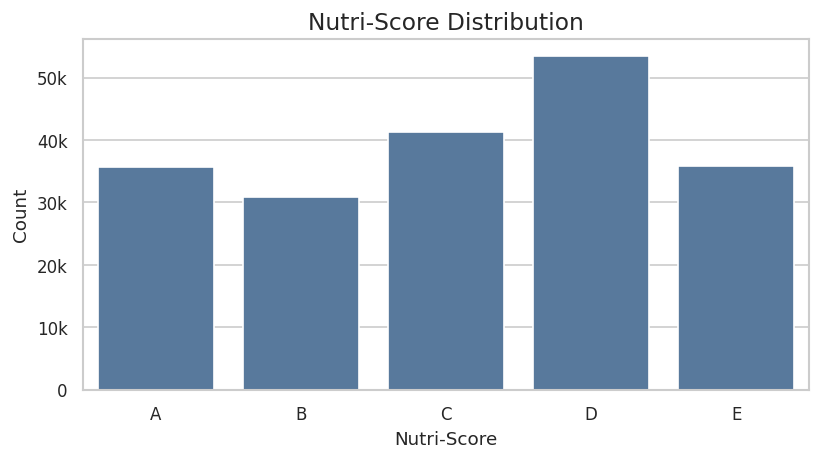

In [ ]:
# Plot the Nutri-Score class distribution.
grade_counts = class_counts.set_index("grade").loc[LABELS, "count"]

plt.figure(figsize=(7, 4))
ax = sns.barplot(x=grade_counts.index, y=grade_counts.values, color="#4C78A8")
plt.title("Nutri-Score Distribution")
plt.xlabel("Nutri-Score")
plt.ylabel("Count")
format_count_axis(ax, axis="y")
plt.tight_layout()
plt.show()


This distribution shows whether the target classes are reasonably represented in the cleaned data. If one or two grades were overwhelmingly dominant, overall accuracy would be less informative. The cleaned dataset still contains enough products in each class to support a meaningful multi-class comparison.


### Average Nutrition by Grade

This heatmap compares the average nutrition values for each Nutri-Score grade.


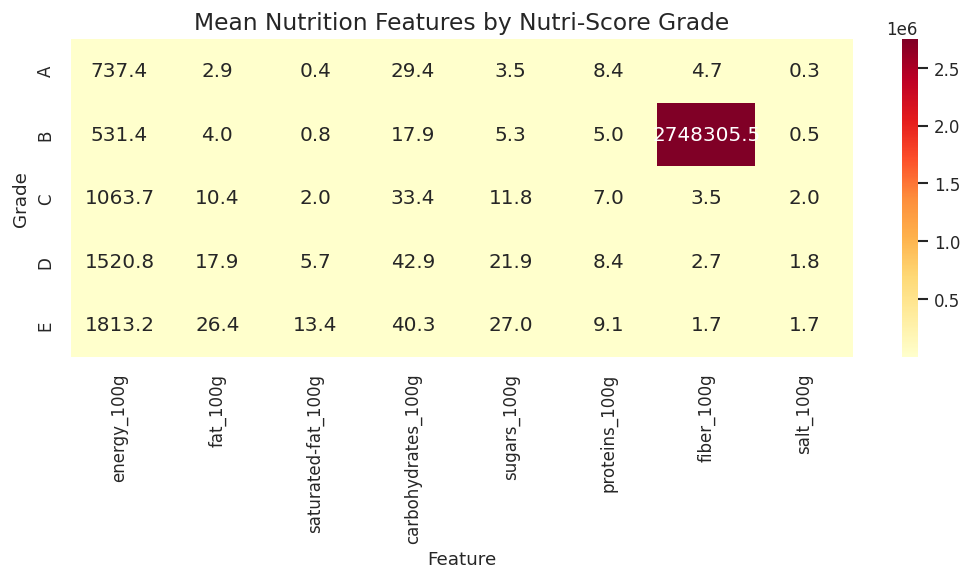

In [ ]:
# Plot average feature values by grade.
plt.figure(figsize=(9, 5))
sns.heatmap(mean_by_grade, annot=True, fmt=".1f", cmap="YlOrRd")
plt.title("Mean Nutrition Features by Nutri-Score Grade")
plt.xlabel("Feature")
plt.ylabel("Grade")
plt.tight_layout()
plt.show()


The heatmap shows a clear pattern across grades. Products with worse Nutri-Score labels generally have higher energy, sugar, saturated fat, and salt values, while the healthier grades tend to have lower averages on those measures. This gives an early sign that the nutrition variables should have predictive value.


# Exploratory Data Analysis

The next sections examine the numeric features in more detail before training any models.


## Feature Distributions

The boxplot below checks whether key nutrition variables separate the Nutri-Score classes beyond just their averages.


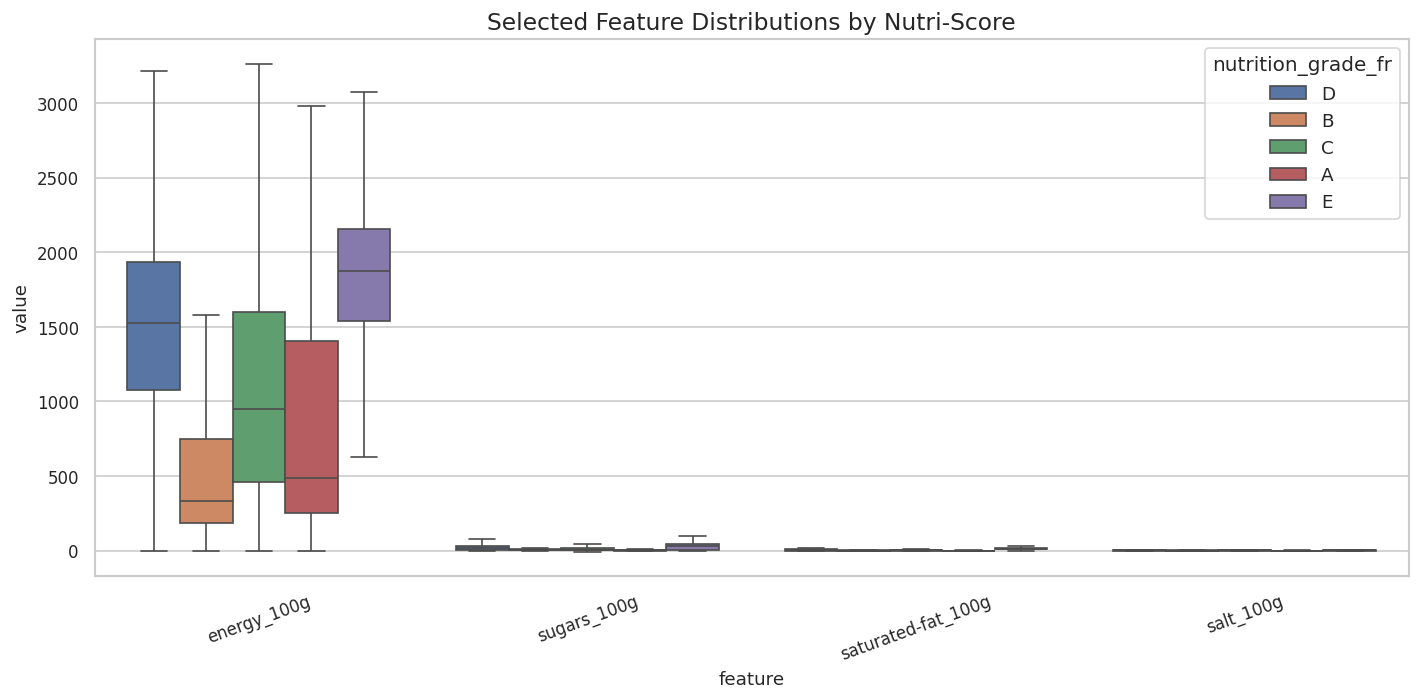

In [ ]:
# Plot selected feature distributions by grade.
plot_features = [col for col in ["energy_100g", "sugars_100g", "saturated-fat_100g", "salt_100g"] if col in ACTIVE_NUMERIC_COLS]
# Reshape the selected features so seaborn can draw one grouped boxplot panel.
if len(plot_features) >= 2:
    melted = model_df[["nutrition_grade_fr", *plot_features]].melt(
        id_vars="nutrition_grade_fr",
        value_vars=plot_features,
        var_name="feature",
        value_name="value",
    )
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=melted, x="feature", y="value", hue="nutrition_grade_fr", showfliers=False)
    plt.title("Selected Feature Distributions by Nutri-Score")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()


The boxplots show noticeable separation between the healthier and less healthy grades, even though there is still overlap. That overlap is important because it suggests the classification task is not trivial, but the overall ordering still supports the idea that these variables carry useful signal.


## Correlations

This heatmap shows how the numeric predictors relate to each other.


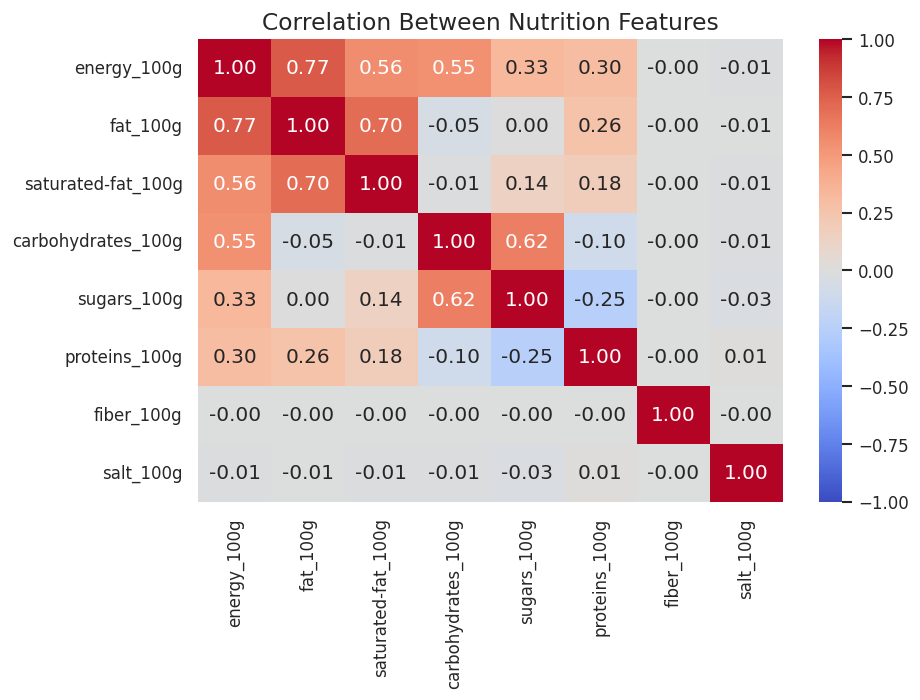

In [ ]:
# Plot the feature correlation matrix.
plt.figure(figsize=(8, 6))
sns.heatmap(model_df[ACTIVE_NUMERIC_COLS].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Between Nutrition Features")
plt.tight_layout()
plt.show()


Several nutrition variables are correlated, which is expected in food data. This matters for two reasons: it helps explain why PCA might compress the data effectively, and it also means the linear models may be working with overlapping information across features.


## Category and Country Coverage

The bar charts below show which categories and countries appear most often in the cleaned subset.


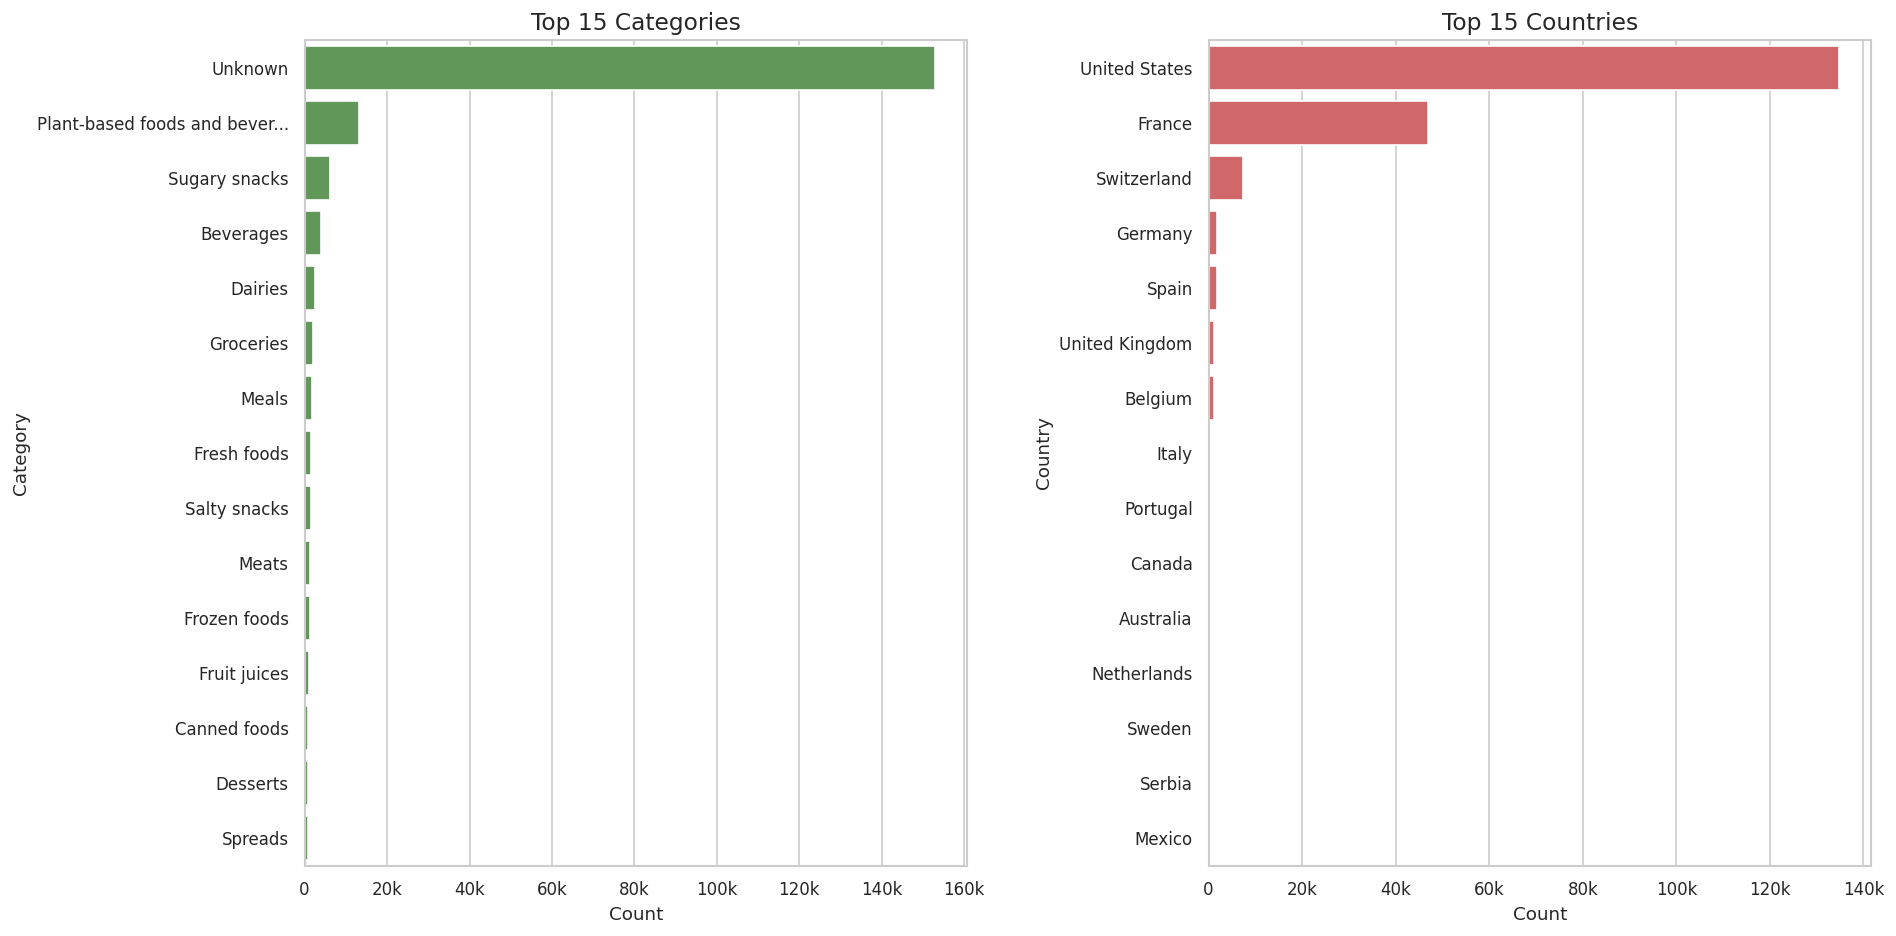

In [ ]:
# Plot the most common categories and countries.
# Focus on the most common values so the chart stays readable.
top_categories_plot = clean_df["main_category_simple"].value_counts().head(15).rename_axis("main_category_simple").reset_index(name="count")
top_countries_plot = clean_df["countries_simple"].value_counts().head(15).rename_axis("country_simple").reset_index(name="count")
top_categories_plot["main_category_short"] = shorten_axis_labels(top_categories_plot["main_category_simple"], max_len=28)
top_countries_plot["country_short"] = shorten_axis_labels(top_countries_plot["country_simple"], max_len=28)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
sns.barplot(data=top_categories_plot, x="count", y="main_category_short", ax=axes[0], color="#59A14F")
axes[0].set_title("Top 15 Categories")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("Category")
format_count_axis(axes[0], axis="x")

sns.barplot(data=top_countries_plot, x="count", y="country_short", ax=axes[1], color="#E15759")
axes[1].set_title("Top 15 Countries")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("Country")
format_count_axis(axes[1], axis="x")

plt.tight_layout(pad=1.2, w_pad=2.5)
plt.show()


These plots show that the cleaned data is not perfectly uniform across categories or countries. That concentration is one reason we bucket rare values into `Other` before one-hot encoding. It also means the final results may reflect where the dataset is densest rather than every food type equally.


## PCA Variance

This plot checks how many principal components are needed to retain most of the numeric information.


Components needed for 95% explained variance: 6


,component,explained_variance_ratio,cumulative_explained_variance
0,PC1,0.324233,0.324233
1,PC2,0.221476,0.545709
2,PC3,0.125037,0.670746
3,PC4,0.124970,0.795716
4,PC5,0.110551,0.906268
5,PC6,0.056550,0.962818
6,PC7,0.034209,0.997027
7,PC8,0.002973,1.000000


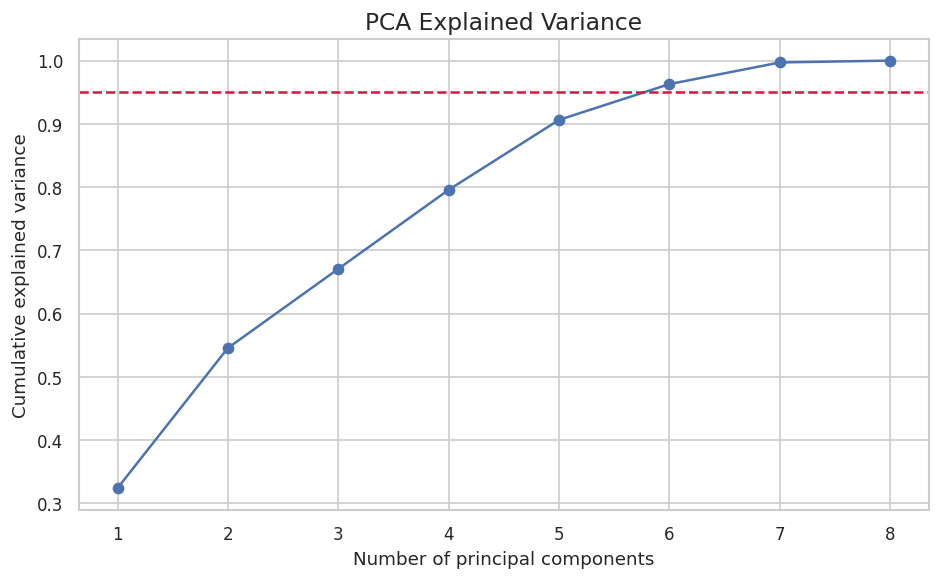

In [ ]:
# Compute PCA explained variance.
# Standardize the numeric features before PCA so large-scale variables do not dominate.
scaled_numeric = StandardScaler().fit_transform(model_df[ACTIVE_NUMERIC_COLS])
pca_full = PCA(random_state=RANDOM_SEED).fit(scaled_numeric)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
pca_component_k = int(np.searchsorted(cum_var, 0.95) + 1)
pca_variance = pd.DataFrame({
    "component": [f"PC{i+1}" for i in range(len(ACTIVE_NUMERIC_COLS))],
    "explained_variance_ratio": pca_full.explained_variance_ratio_,
    "cumulative_explained_variance": cum_var,
})
print("Components needed for 95% explained variance:", pca_component_k)
display(pca_variance)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(ACTIVE_NUMERIC_COLS) + 1), cum_var, marker="o")
plt.axhline(0.95, color="crimson", linestyle="--")
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA Explained Variance")
plt.xticks(range(1, len(ACTIVE_NUMERIC_COLS) + 1))
plt.tight_layout()
plt.show()


The explained-variance curve shows how much dimensionality reduction is possible before losing too much information. If most of the variance is captured in a small number of components, then PCA becomes a reasonable baseline transformation to test against the original feature space.


## PCA Projection

This scatterplot projects the products into two principal components to see whether the grades form visible clusters.


/tmp/ipykernel_10511/299997228.py:99: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=max(1, int(round(len(g) * fraction))), random_state=seed))


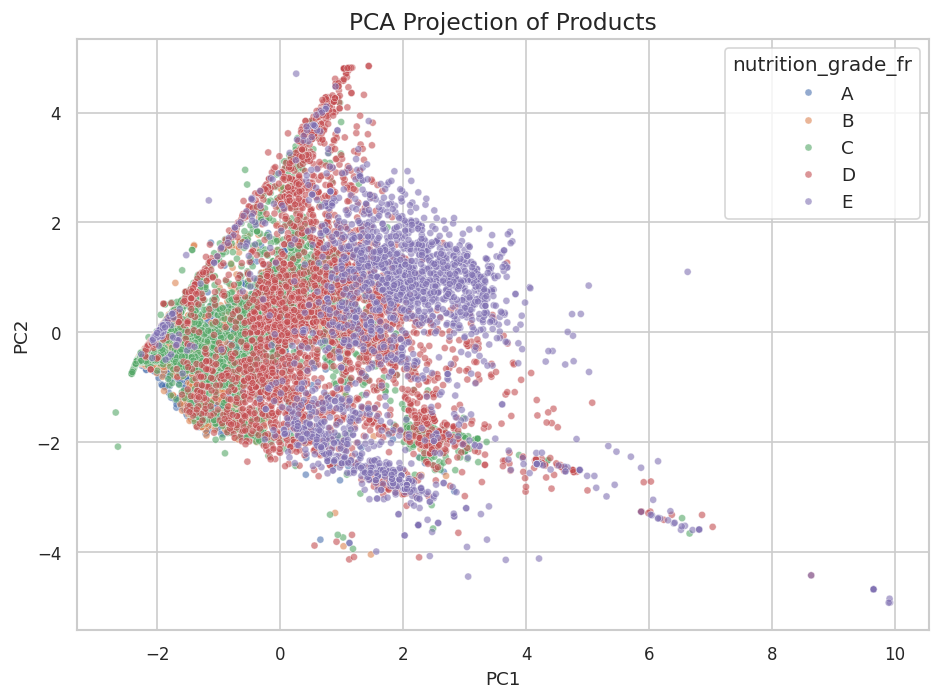

In [ ]:
# Plot the first two principal components.
if len(ACTIVE_NUMERIC_COLS) >= 2:
    pca_plot = PCA(n_components=2, random_state=RANDOM_SEED).fit_transform(scaled_numeric)
    pca_plot_df = pd.DataFrame({"pc1": pca_plot[:, 0], "pc2": pca_plot[:, 1], "nutrition_grade_fr": model_df["nutrition_grade_fr"].to_numpy()})
    pca_plot_df = stratified_cap(pca_plot_df, "nutrition_grade_fr", min(12000, len(pca_plot_df)))
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=pca_plot_df, x="pc1", y="pc2", hue="nutrition_grade_fr", alpha=0.6, s=18)
    plt.title("PCA Projection of Products")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()
    plt.show()


The PCA projection is useful for visual intuition, but it usually shows partial overlap rather than perfectly separated groups. That is expected. The projection compresses the data into only two dimensions, so the more important question is whether PCA helps the prediction models when compared with the full numeric feature set.


# Train/Test Split and Modeling Strategy

We use a stratified train/test split so that the train and test sets preserve roughly the same class distribution. That makes the evaluation more stable for a multi-class problem like this one.

For the baseline comparison, we include a mix of models with different assumptions:

- Logistic regression on numeric features.
- Logistic regression with PCA-transformed numeric features.
- Logistic regression with numeric features plus metadata.
- Decision tree.
- Random forest.
- K-means with a majority-label mapping as an unsupervised reference point.

This combination lets us compare linear, nonlinear, ensemble, and unsupervised approaches on the same prediction task.


In [ ]:
# Create the train/test split.
train_df, test_df = train_test_split(
    model_df,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=model_df["nutrition_grade_fr"],
)

X_train = train_df[ACTIVE_NUMERIC_COLS + ["main_category_model", "country_model"]]
X_test = test_df[ACTIVE_NUMERIC_COLS + ["main_category_model", "country_model"]]
y_train = train_df["nutrition_grade_fr"]
y_test = test_df["nutrition_grade_fr"]


# Baseline Model Training

The next cell fits all baseline models and stores their metrics, predictions, and confusion matrices.

We evaluate each model with three summary metrics:

- Accuracy for overall correctness.
- Macro F1 to treat each grade more evenly.
- Weighted F1 to account for support differences across classes.

Using several metrics is important because a model can look good on raw accuracy while still performing unevenly across grades.


In [ ]:
# Fit the baseline models.
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

numeric_preprocessor = ColumnTransformer([
    ("num", numeric_transformer, ACTIVE_NUMERIC_COLS),
])

metadata_preprocessor = ColumnTransformer([
    ("num", numeric_transformer, ACTIVE_NUMERIC_COLS),
    ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=25), ["main_category_model", "country_model"]),
])

class KMeansLabelMapper:
    """Wrap K-means with a majority-label mapping for evaluation."""
    # Map each cluster to its majority training label.
    def __init__(self, n_clusters=5, random_state=RANDOM_SEED, n_init=10):
        """Store the clustering settings used during fitting."""
        self.n_clusters = n_clusters
        self.random_state = random_state
        self.n_init = n_init

    def fit(self, X, y):
        """Fit K-means and learn the majority class for each cluster."""
        self.kmeans_ = KMeans(n_clusters=self.n_clusters, random_state=self.random_state, n_init=self.n_init)
        clusters = self.kmeans_.fit_predict(X)
        # Convert unsupervised cluster IDs into class predictions using training labels.
        cluster_frame = pd.DataFrame({"cluster": clusters, "label": np.asarray(y)})
        self.cluster_to_label_ = (
            cluster_frame.groupby("cluster")["label"]
            .agg(lambda s: s.value_counts().idxmax())
            .to_dict()
        )
        self.default_label_ = pd.Series(np.asarray(y)).value_counts().idxmax()
        return self

    def predict(self, X):
        """Predict labels by assigning each cluster its learned majority class."""
        clusters = self.kmeans_.predict(X)
        return np.array([self.cluster_to_label_.get(cluster, self.default_label_) for cluster in clusters])

def evaluate_predictions(y_true, y_pred, model_name):
    """Return summary metrics, row-level predictions, and a confusion matrix."""
    metrics_row = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
    }
    pred_df = pd.DataFrame({"actual": y_true.to_numpy(), "predicted": y_pred})
    cm = pd.DataFrame(confusion_matrix(y_true, y_pred, labels=LABELS), index=LABELS, columns=LABELS)
    return metrics_row, pred_df, cm

models = {
    "logistic_numeric": Pipeline([
        ("prep", numeric_preprocessor),
        ("clf", LogisticRegression(max_iter=300, multi_class="auto")),
    ]),
    "logistic_pca_numeric": Pipeline([
        ("prep", numeric_preprocessor),
        ("pca", PCA(n_components=pca_component_k, random_state=RANDOM_SEED)),
        ("clf", LogisticRegression(max_iter=300, multi_class="auto")),
    ]),
    "logistic_numeric_metadata": Pipeline([
        ("prep", metadata_preprocessor),
        ("clf", LogisticRegression(max_iter=300, multi_class="auto")),
    ]),
    "decision_tree_numeric": Pipeline([
        ("prep", numeric_preprocessor),
        ("clf", DecisionTreeClassifier(max_depth=10, min_samples_leaf=20, random_state=RANDOM_SEED)),
    ]),
    "random_forest_numeric": Pipeline([
        ("prep", numeric_preprocessor),
        ("clf", RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1)),
    ]),
    "kmeans_numeric": Pipeline([
        ("prep", numeric_preprocessor),
        ("clf", KMeansLabelMapper(n_clusters=len(LABELS), random_state=RANDOM_SEED)),
    ]),
}

baseline_rows = []
pred_store = {}
fit_store = {}
confusion_store = {}

for name, model in models.items():
    # Keep each model's metrics, fitted object, and predictions for later comparison.
    fitted_model = model.fit(X_train, y_train)
    predictions = fitted_model.predict(X_test)
    metrics_row, pred_df, cm = evaluate_predictions(y_test, predictions, name)
    baseline_rows.append(metrics_row)
    pred_store[name] = pred_df
    fit_store[name] = fitted_model
    confusion_store[name] = cm

baseline_results = pd.DataFrame(baseline_rows).sort_values("accuracy", ascending=False).reset_index(drop=True)
baseline_results


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,model,accuracy,macro_f1,weighted_f1
0,random_forest_numeric,0.943422,0.941255,0.943439
1,decision_tree_numeric,0.844061,0.839623,0.846825
2,logistic_numeric_metadata,0.660910,0.664319,0.662177
3,logistic_numeric,0.619167,0.620873,0.620346
4,logistic_pca_numeric,0.615820,0.617596,0.616922
5,kmeans_numeric,0.356589,0.264063,0.253039


# Baseline Model Comparison

After training the baseline models, we compare their performance using several evaluation views.


## Model Metrics

This chart compares the main evaluation metrics for every baseline model.


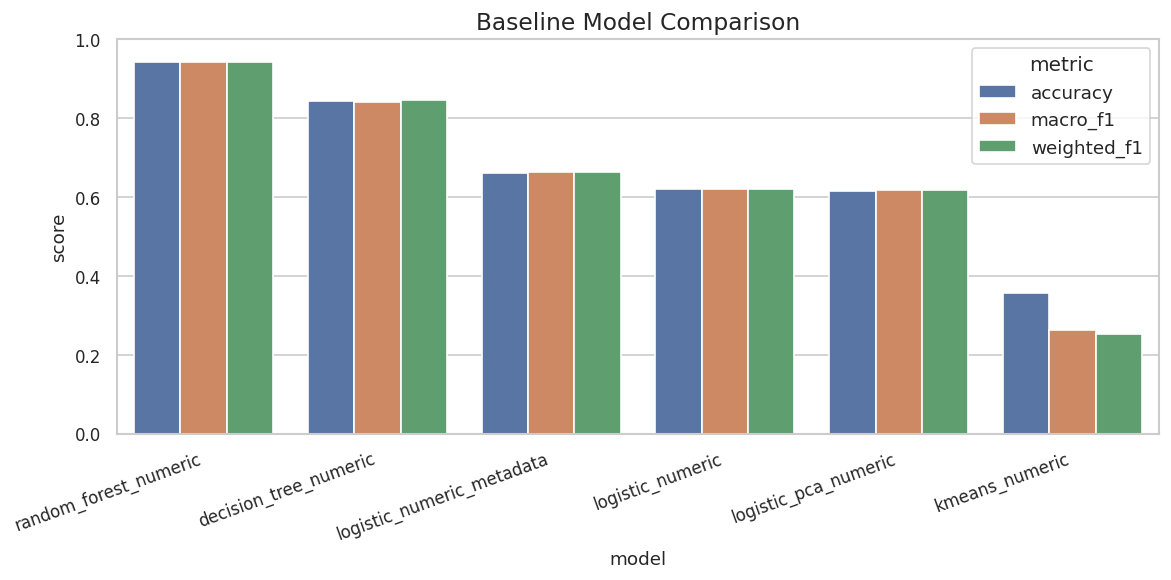

In [ ]:
# Plot the baseline model metrics.
plt.figure(figsize=(10, 5))
# Convert the results table to long format for a grouped comparison chart.
baseline_melted = baseline_results.melt(id_vars="model", value_vars=["accuracy", "macro_f1", "weighted_f1"], var_name="metric", value_name="score")
sns.barplot(data=baseline_melted, x="model", y="score", hue="metric")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1)
plt.title("Baseline Model Comparison")
plt.tight_layout()
plt.show()


This comparison shows which models perform strongly across multiple metrics rather than only one. In this project, the tree-based models are expected to do well because they can capture nonlinear relationships and interactions among the nutrition variables.


## Confusion Matrix

The next plot focuses on the strongest baseline model and shows where its predictions are correct or incorrect.


Best baseline: random_forest_numeric


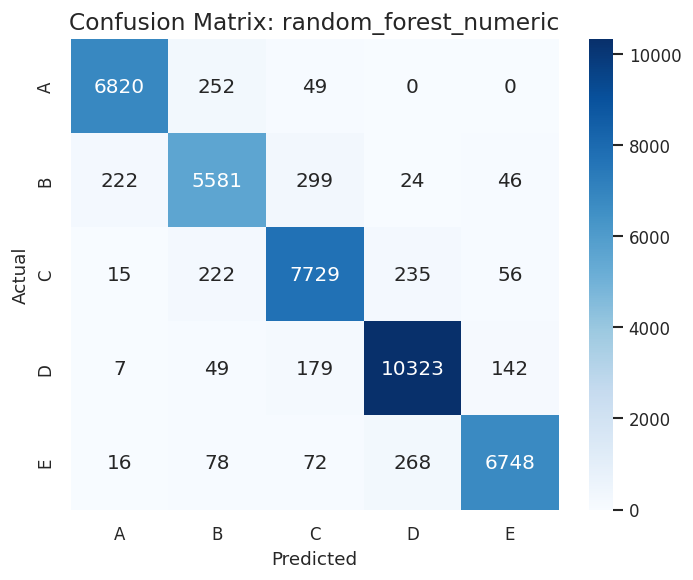

,precision,recall,f1-score,support
A,0.963,0.958,0.960,7121.000
B,0.903,0.904,0.904,6172.000
C,0.928,0.936,0.932,8257.000
D,0.951,0.965,0.958,10700.000
E,0.965,0.940,0.952,7182.000
accuracy,0.943,0.943,0.943,0.943
macro avg,0.942,0.940,0.941,39432.000
weighted avg,0.944,0.943,0.943,39432.000


In [ ]:
# Plot the best baseline confusion matrix and report.
best_baseline_name = baseline_results.iloc[0]["model"]
best_cm = confusion_store[best_baseline_name]
print("Best baseline:", best_baseline_name)

plt.figure(figsize=(6, 5))
sns.heatmap(best_cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix: {best_baseline_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

best_pred_df = pred_store[best_baseline_name]
display(pd.DataFrame(classification_report(best_pred_df["actual"], best_pred_df["predicted"], labels=LABELS, output_dict=True)).T.round(3))


The confusion matrix shows that the strongest baseline gets many predictions right, but the mistakes are usually concentrated near neighboring grades. That pattern makes sense because adjacent Nutri-Score labels often correspond to products with similar nutritional profiles.


## Error Analysis and Model Interpretation

After identifying the best baseline, we look at feature importance when the model supports it and then inspect the most common misclassification pairs.

This part helps show not only which model performs best, but also why it performs well and where it still makes mistakes.


## Feature Importance

If the best baseline is a tree-based model, this plot shows which nutrition variables contribute most to the predictions.


,feature,importance
7,salt_100g,0.202738
2,saturated-fat_100g,0.174313
4,sugars_100g,0.142820
6,fiber_100g,0.120546
0,energy_100g,0.110723
1,fat_100g,0.095224
5,proteins_100g,0.082572
3,carbohydrates_100g,0.071064


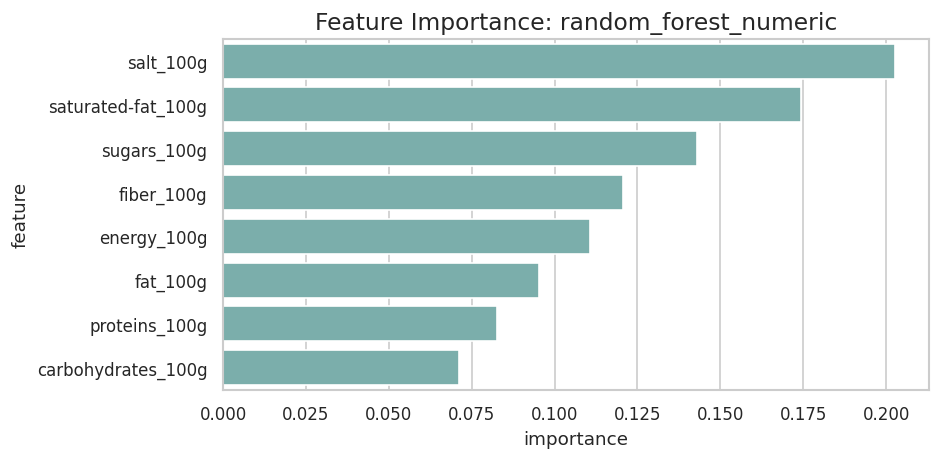

In [ ]:
# Plot feature importance for the best tree-based baseline.
if best_baseline_name in {"random_forest_numeric", "decision_tree_numeric"}:
    importances = fit_store[best_baseline_name].named_steps["clf"].feature_importances_
    feature_importance_df = pd.DataFrame({"feature": ACTIVE_NUMERIC_COLS, "importance": importances}).sort_values("importance", ascending=False)
    display(feature_importance_df)

    plt.figure(figsize=(8, 4))
    sns.barplot(data=feature_importance_df, x="importance", y="feature", color="#72B7B2")
    plt.title(f"Feature Importance: {best_baseline_name}")
    plt.tight_layout()
    plt.show()


This plot helps explain why the model performs well. The most important variables align with the EDA, especially salt, saturated fat, sugar, and fiber.

## Misclassifications

This section isolates the most common errors made by the best baseline.


,actual,predicted,count
3,B,C,299
17,E,D,268
0,A,B,252
8,C,D,235
2,B,A,222
7,C,B,222
12,D,C,179
13,D,E,142
15,E,B,78
16,E,C,72


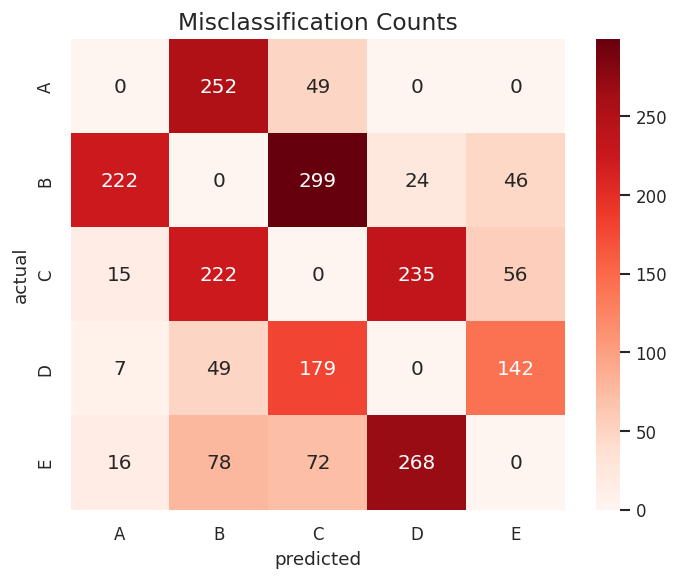

In [ ]:
# Summarize and plot the most common misclassifications.
# Count only the mistakes so we can see which grade pairs are most often confused.
mis_pairs = (
    best_pred_df.loc[best_pred_df["actual"] != best_pred_df["predicted"]]
    .groupby(["actual", "predicted"])
    .size()
    .reset_index(name="count")
)
display(mis_pairs.sort_values("count", ascending=False).head(10))
mis_pivot = mis_pairs.pivot(index="actual", columns="predicted", values="count").fillna(0) if not mis_pairs.empty else pd.DataFrame(0, index=LABELS, columns=LABELS)

plt.figure(figsize=(6, 5))
sns.heatmap(mis_pivot, annot=True, fmt=".0f", cmap="Reds")
plt.title("Misclassification Counts")
plt.tight_layout()
plt.show()


Most of the larger error counts appear between adjacent labels rather than across extreme grades such as A and E. That is a useful result because it suggests the model is usually wrong in a limited way instead of making completely unrealistic predictions.


# Hyperparameter Tuning

After comparing the baselines, we test whether a small amount of tuning improves the stronger tree-based models.

Instead of doing an extremely large search, we run a lightweight grid search on stratified samples of the training data. That keeps the notebook practical to run while still testing whether a modest amount of tuning improves the decision tree and random forest baselines.


/tmp/ipykernel_10511/299997228.py:99: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=max(1, int(round(len(g) * fraction))), random_state=seed))


Tuning rows: 29999


,params,mean_test_score,rank_test_score
1,"{'clf__max_depth': None, 'clf__min_samples_lea...",0.891296,1
0,"{'clf__max_depth': None, 'clf__min_samples_lea...",0.890196,2
5,"{'clf__max_depth': 16, 'clf__min_samples_leaf'...",0.888330,3
4,"{'clf__max_depth': 16, 'clf__min_samples_leaf'...",0.886530,4
3,"{'clf__max_depth': None, 'clf__min_samples_lea...",0.877963,5
7,"{'clf__max_depth': 16, 'clf__min_samples_leaf'...",0.877663,6
6,"{'clf__max_depth': 16, 'clf__min_samples_leaf'...",0.876563,7
2,"{'clf__max_depth': None, 'clf__min_samples_lea...",0.876496,8


,params,mean_test_score,rank_test_score
6,"{'clf__max_depth': 16, 'clf__min_samples_leaf'...",0.839662,1
7,"{'clf__max_depth': 16, 'clf__min_samples_leaf'...",0.830761,2
3,"{'clf__max_depth': 12, 'clf__min_samples_leaf'...",0.830561,3
4,"{'clf__max_depth': 12, 'clf__min_samples_leaf'...",0.823794,4
8,"{'clf__max_depth': 16, 'clf__min_samples_leaf'...",0.804060,5
5,"{'clf__max_depth': 12, 'clf__min_samples_leaf'...",0.798893,6
0,"{'clf__max_depth': 8, 'clf__min_samples_leaf':...",0.780159,7
1,"{'clf__max_depth': 8, 'clf__min_samples_leaf':...",0.776992,8


,model,best_params,accuracy,macro_f1,weighted_f1
0,random_forest_tuned,"{'clf__max_depth': None, 'clf__min_samples_lea...",0.904722,0.901554,0.904820
1,decision_tree_tuned,"{'clf__max_depth': 16, 'clf__min_samples_leaf'...",0.852911,0.850383,0.853448


,model,accuracy
0,random_forest_baseline,0.943422
1,random_forest_tuned,0.904722
2,decision_tree_baseline,0.844061
3,decision_tree_tuned,0.852911


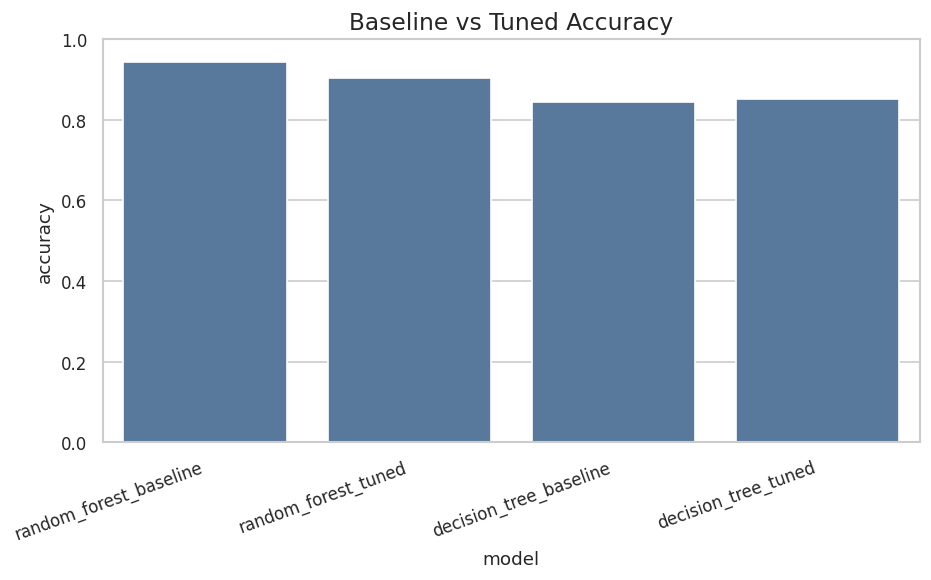

In [ ]:
# Tune the tree-based models on a smaller stratified sample.
tuning_df = stratified_cap(train_df, "nutrition_grade_fr", TUNING_SAMPLE_SIZE)
X_tune = tuning_df[ACTIVE_NUMERIC_COLS + ["main_category_model", "country_model"]]
y_tune = tuning_df["nutrition_grade_fr"]
print("Tuning rows:", len(tuning_df))

# Keep the search grid small enough to run in a notebook but broad enough to test improvement.
rf_grid = GridSearchCV(
    estimator=Pipeline([
        ("prep", numeric_preprocessor),
        ("clf", RandomForestClassifier(random_state=RANDOM_SEED, n_jobs=-1)),
    ]),
    param_grid={
        "clf__n_estimators": [100, 150],
        "clf__max_depth": [None, 16],
        "clf__min_samples_leaf": [1, 5],
    },
    scoring="accuracy",
    cv=3,
    n_jobs=1,
)
rf_grid.fit(X_tune, y_tune)
rf_tune_table = pd.DataFrame(rf_grid.cv_results_)[["params", "mean_test_score", "rank_test_score"]].sort_values(["rank_test_score", "mean_test_score"])
display(rf_tune_table.head(8))
best_rf_model = rf_grid.best_estimator_
best_rf_predictions = best_rf_model.predict(X_test)
rf_tuned_metrics, _, _ = evaluate_predictions(y_test, best_rf_predictions, "random_forest_tuned")

dt_grid = GridSearchCV(
    estimator=Pipeline([
        ("prep", numeric_preprocessor),
        ("clf", DecisionTreeClassifier(random_state=RANDOM_SEED)),
    ]),
    param_grid={
        "clf__max_depth": [8, 12, 16],
        "clf__min_samples_leaf": [10, 20, 40],
    },
    scoring="accuracy",
    cv=3,
    n_jobs=1,
)
dt_grid.fit(X_tune, y_tune)
dt_tune_table = pd.DataFrame(dt_grid.cv_results_)[["params", "mean_test_score", "rank_test_score"]].sort_values(["rank_test_score", "mean_test_score"])
display(dt_tune_table.head(8))
best_dt_model = dt_grid.best_estimator_
best_dt_predictions = best_dt_model.predict(X_test)
dt_tuned_metrics, _, _ = evaluate_predictions(y_test, best_dt_predictions, "decision_tree_tuned")

tuning_results = pd.DataFrame([
    {"model": "random_forest_tuned", "best_params": rf_grid.best_params_, **rf_tuned_metrics},
    {"model": "decision_tree_tuned", "best_params": dt_grid.best_params_, **dt_tuned_metrics},
]).sort_values("accuracy", ascending=False)
display(tuning_results)

tuned_compare = pd.DataFrame([
    {"model": "random_forest_baseline", "accuracy": float(baseline_results.loc[baseline_results["model"] == "random_forest_numeric", "accuracy"].iloc[0])},
    {"model": "random_forest_tuned", "accuracy": float(rf_tuned_metrics["accuracy"])},
    {"model": "decision_tree_baseline", "accuracy": float(baseline_results.loc[baseline_results["model"] == "decision_tree_numeric", "accuracy"].iloc[0])},
    {"model": "decision_tree_tuned", "accuracy": float(dt_tuned_metrics["accuracy"])},
])
display(tuned_compare)

plt.figure(figsize=(8, 5))
sns.barplot(data=tuned_compare, x="model", y="accuracy", color="#4E79A7")
plt.title("Baseline vs Tuned Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


## Baseline vs Tuned Models

This chart compares the tuned tree models against their baseline versions.


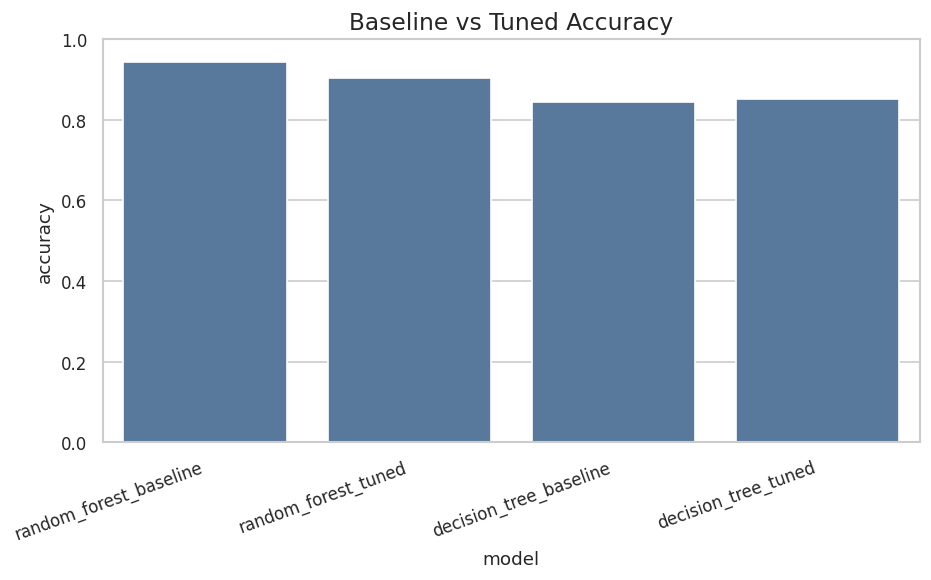

In [ ]:
# Plot the baseline versus tuned accuracy comparison.
plt.figure(figsize=(8, 5))
sns.barplot(data=tuned_compare, x="model", y="accuracy", color="#4E79A7")
plt.title("Baseline vs Tuned Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


This comparison shows whether a small amount of hyperparameter tuning produces a meaningful gain. Even if the improvement is modest, it helps show that we tested model refinement rather than stopping at the first reasonable baseline.


## Tuning Notes

This tuning step is intentionally lightweight. We use a stratified sample for the grid search and then evaluate the best settings on the held-out test set so the final comparison stays fair.


# Final Results

This section pulls the main results together and summarizes the final outcome of the project.


In [ ]:
# Combine the baseline and tuned results.
final_results = pd.concat([
    baseline_results,
    tuning_results[["model", "accuracy", "macro_f1", "weighted_f1"]],
], ignore_index=True).sort_values("accuracy", ascending=False).reset_index(drop=True)
display(final_results)

best_model_row = baseline_results.iloc[0]
pca_row = baseline_results.loc[baseline_results["model"] == "logistic_pca_numeric"].iloc[0]
best_overall = final_results.iloc[0]
summary_table = pd.DataFrame([
    {"metric": "Best baseline model", "value": best_model_row["model"]},
    {"metric": "Best baseline accuracy", "value": round(best_model_row["accuracy"], 4)},
    {"metric": "Best baseline macro F1", "value": round(best_model_row["macro_f1"], 4)},
    {"metric": "PCA logistic accuracy", "value": round(pca_row["accuracy"], 4)},
    {"metric": "Tuned random forest accuracy", "value": round(rf_tuned_metrics["accuracy"], 4)},
    {"metric": "Tuned decision tree accuracy", "value": round(dt_tuned_metrics["accuracy"], 4)},
    {"metric": "Best overall model after tuning", "value": best_overall["model"]},
])
display(summary_table)


,model,accuracy,macro_f1,weighted_f1
0,random_forest_numeric,0.943422,0.941255,0.943439
1,random_forest_tuned,0.904722,0.901554,0.904820
2,decision_tree_tuned,0.852911,0.850383,0.853448
3,decision_tree_numeric,0.844061,0.839623,0.846825
4,logistic_numeric_metadata,0.660910,0.664319,0.662177
5,logistic_numeric,0.619167,0.620873,0.620346
6,logistic_pca_numeric,0.615820,0.617596,0.616922
7,kmeans_numeric,0.356589,0.264063,0.253039


,metric,value
0,Best baseline model,random_forest_numeric
1,Best baseline accuracy,0.9434
2,Best baseline macro F1,0.9413
3,PCA logistic accuracy,0.6158
4,Tuned random forest accuracy,0.9047
5,Tuned decision tree accuracy,0.8529
6,Best overall model after tuning,random_forest_numeric


The final summary table collects the strongest baseline and tuned results in one place. This makes it easier to state the final outcome clearly: which model performed best, whether PCA helped, and whether tuning changed the ranking.


## Summary

The table above collects the strongest baseline results and the tuned tree-based results in one place.


# Challenges and Obstacles Faced

A few issues made this project harder than a simple textbook classification task:

- The original dataset is extremely large, so some notebook steps need sampling or simplified searches to stay runnable.
- Many columns in Open Food Facts have substantial missingness, which means the usable modeling subset is much smaller than the raw file.
- Category and country metadata are informative, but they also create high-cardinality encoding problems if used without bucketing.
- Nutri-Score grades are ordered categories, so many errors happen between adjacent labels that are nutritionally similar.
- Because this is a notebook project, we had to balance stronger modeling ideas against runtime and readability constraints.



  ## Conclusion

  This project shows that Nutri-Score can be predicted well from a small set of nutrition features. The strongest model was the baseline random forest,
  which achieved an accuracy of 0.9434 and a macro F1 score of 0.9413. That result suggests the numeric nutrition variables alone already contain
  enough information to classify products into Nutri-Score grades at a high level of accuracy.

  ### Key Findings

  - The baseline random forest clearly outperformed every other model and remained the best model even after tuning.
  - The tuned random forest did not improve performance and instead dropped to 0.9047 accuracy.
  - The tuned decision tree improved over the baseline decision tree, rising from 0.8441 to 0.8529 accuracy.
  - The tree-based models clearly outperformed the logistic regression baselines.
  - Adding metadata helped logistic regression somewhat, since logistic_numeric_metadata performed better than the numeric-only logistic models.
  - PCA did not improve logistic regression, since logistic_pca_numeric performed slightly worse than logistic_numeric.
  - Light hyperparameter tuning did not improve the random forest, which suggests the original baseline settings were already strong for this task.
  - K-means performed poorly compared with the supervised models, which suggests that the class structure is not recovered well through unsupervised
    clustering alone.

  ### Limitations

  - The notebook uses a cleaned subset with complete nutrition fields for the active features.
  - Ingredient text was not modeled directly.
  - Country and category representation are still uneven.
  - The tuning grid was intentionally small, so stronger tuning strategies were not fully explored.

  ### Possible Extensions

  - Add ingredient text features with TF-IDF or embeddings.
  - Try gradient-boosted tree models such as XGBoost or LightGBM.
  - Model Nutri-Score as an ordinal target instead of a standard multi-class label.
  - Test category-specific models to see whether separate food groups behave differently.